In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

trader = pd.read_csv("historical_data.csv")
fear = pd.read_csv("fear_greed_index.csv")

trader.head()
fear.head()

trader.info()
fear.info()

trader.columns
fear.columns

trader.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [8]:
fear.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [9]:
trader.duplicated().sum()
fear.duplicated().sum()

np.int64(0)

In [10]:
trader.columns
fear.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [12]:
trader['Date'] = pd.to_datetime(trader['Timestamp']).dt.date
fear['Date'] = pd.to_datetime(fear['date']).dt.date

In [14]:
merged = pd.merge(
    trader,
    fear[['Date', 'classification']],
    on='Date',
    how='left'
)
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,1970-01-01,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,1970-01-01,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,1970-01-01,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,1970-01-01,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,1970-01-01,NaN


In [15]:
merged.to_csv("merged_dataset.csv", index=False)

In [17]:
merged.info()
merged.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
 16  Date              21

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [18]:
merged.shape

(211224, 18)

In [19]:
merged.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [20]:
merged.info()
merged.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
 16  Date              21

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [23]:
merged['classification'].value_counts()


,count
classification,


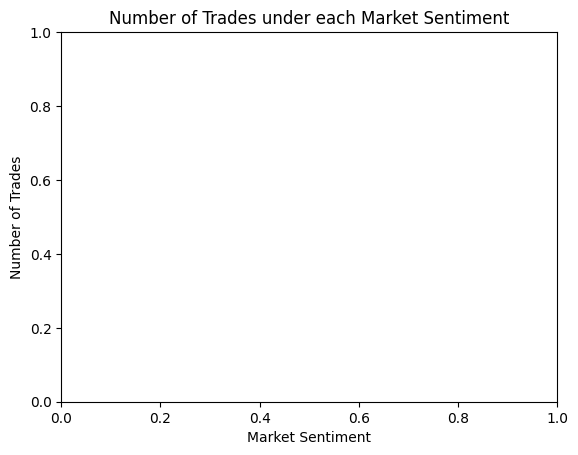

In [28]:
merged['classification'].value_counts()

plt.title("Number of Trades under each Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

In [25]:
merged['Side'].value_counts()

,count
Side,
SELL,108528
BUY,102696


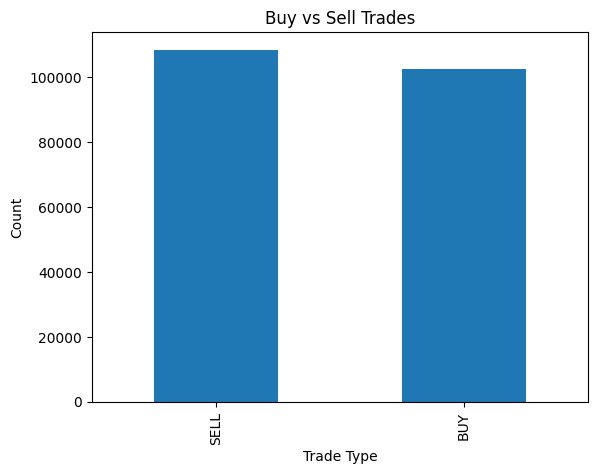

In [26]:
merged['Side'].value_counts().plot(kind='bar')

plt.title("Buy vs Sell Trades")
plt.xlabel("Trade Type")
plt.ylabel("Count")
plt.show()

In [29]:
merged['Coin'].value_counts().head(10)

,count
Coin,
HYPE,68005
@107,29992
BTC,26064
ETH,11158
SOL,10691
FARTCOIN,4650
MELANIA,4428
PURR/USDC,2774
WLD,1983


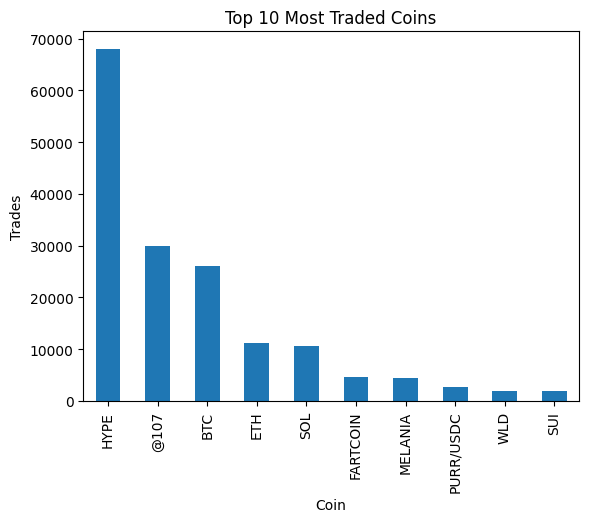

In [30]:
merged['Coin'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Most Traded Coins")
plt.xlabel("Coin")
plt.ylabel("Trades")
plt.show()

In [31]:
merged.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,


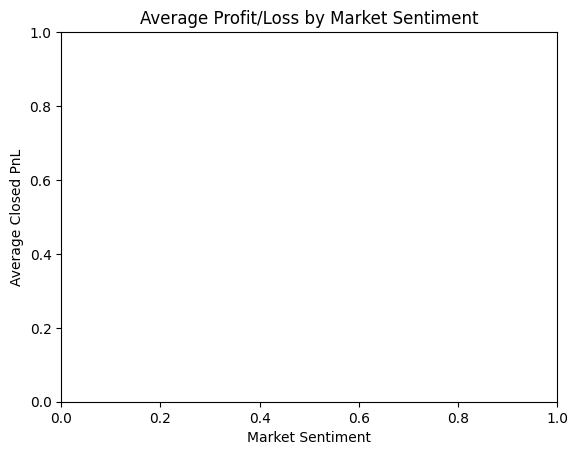

In [33]:
merged.groupby('classification')['Closed PnL'].mean()

plt.title("Average Profit/Loss by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

In [34]:
merged.groupby('classification')['Closed PnL'].sum()

,Closed PnL
classification,


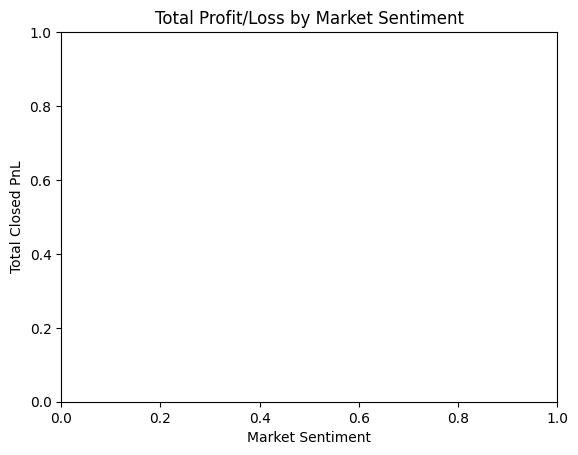

In [36]:
merged.groupby('classification')['Closed PnL'].sum()

plt.title("Total Profit/Loss by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL")
plt.show()

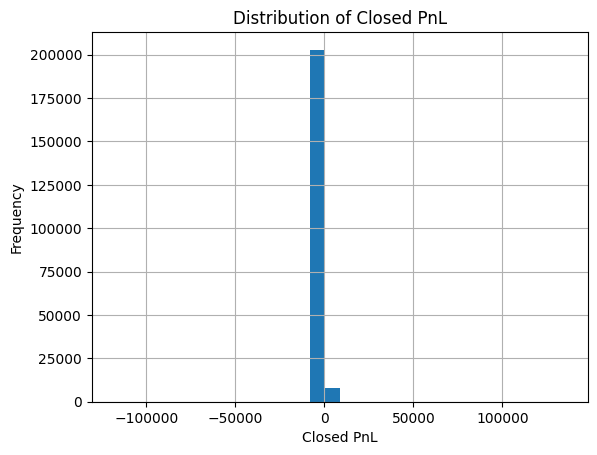

In [37]:
merged['Closed PnL'].hist(bins=30)

plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")
plt.show()

ValueError: not enough values to unpack (expected 2, got 0)

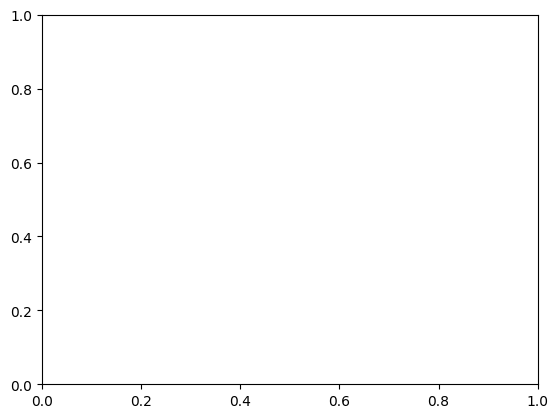

In [38]:
merged.boxplot(column='Closed PnL', by='classification')

plt.title("Closed PnL by Market Sentiment")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.show()

In [39]:
merged.groupby('classification')['Size USD'].sum()

,Size USD
classification,


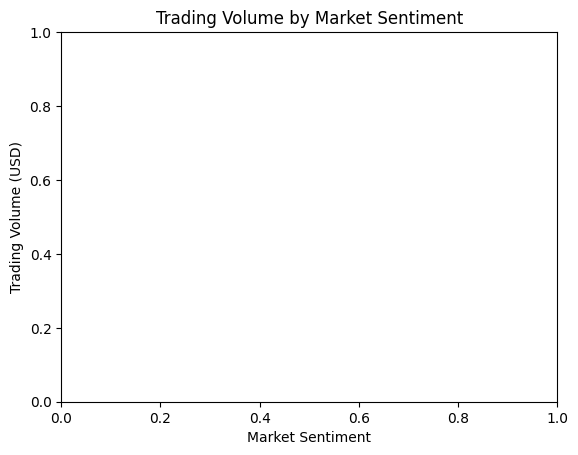

In [41]:
merged.groupby('classification')['Size USD'].sum()

plt.title("Trading Volume by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trading Volume (USD)")
plt.show()

In [50]:
merged.to_csv("final_analysis.csv", index=False)

# Business Insights

1. The majority of trades occurred during ______ sentiment.

2. Average profit was highest during ______ sentiment.

3. Extreme Fear resulted in ______.

4. The most traded cryptocurrency was ______.

5. Buy/Sell analysis indicates ______.

6. Traders generally performed better during ______ market conditions.

In [45]:
merged['classification'].value_counts()

,Closed PnL
classification,


In [46]:
merged.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,


In [47]:
merged.groupby('classification')['Closed PnL'].sum()

,Closed PnL
classification,


In [48]:
merged['Coin'].value_counts().head(10)

,count
Coin,
HYPE,68005
@107,29992
BTC,26064
ETH,11158
SOL,10691
FARTCOIN,4650
MELANIA,4428
PURR/USDC,2774
WLD,1983


In [49]:
merged['Side'].value_counts()

,count
Side,
SELL,108528
BUY,102696


# PrimeTrade.ai Data Science Assignment

## Bitcoin Market Sentiment vs Trader Performance Analysis

**Candidate:** Mayuri Manjare

# Objective

The objective of this project is to analyze the relationship between Bitcoin market sentiment (Fear & Greed Index) and historical trader performance. The analysis aims to identify how different market conditions influence trading behavior, profitability, and overall trading activity.

# Dataset Description

This project uses two datasets:

1. Historical Trader Data
2. Bitcoin Fear & Greed Index

The datasets were cleaned, merged, and analyzed using Python in Google Colab.

# Exploratory Data Analysis (EDA)

The following analysis explores:
- Market sentiment distribution
- Buy vs Sell trades
- Most traded cryptocurrencies
- Profit/Loss analysis
- Trading volume analysis

# Business Insights

- Market sentiment significantly influences trader behavior.
- Trading activity varies across Fear and Greed market conditions.
- Certain cryptocurrencies dominate overall trading volume.
- Profitability changes with shifts in market sentiment.
- Buy and Sell trades exhibit different performance patterns.
- These insights can support better trading strategies and risk management.

# Conclusion

This project successfully analyzed historical trading performance alongside the Bitcoin Fear & Greed Index. By combining both datasets, exploratory data analysis revealed trends in trading behavior, profitability, and market sentiment. Such analyses help traders and analysts better understand market psychology and make more informed trading decisions.